# Locally Linear Embedding (LLE)

## Co je Locally Linear Embedding?

Locally Linear Embedding (LLE) je nelineární metoda redukce dimenzionality, která se zaměřuje na zachování lokální struktury dat. Na rozdíl od lineárních metod jako PCA, LLE dokáže odhalit nelineární strukturu dat a je zvláště vhodná pro data, která leží na nebo v blízkosti nízkodimenzionální variety (manifold).

### Klíčové vlastnosti LLE:

- **Zachování lokální struktury**: Zaměřuje se na lokální vztahy mezi datovými body
- **Nelineární redukce**: Dokáže zachytit nelineární struktury a vztahy v datech
- **Bez parametrických modelů**: Nevyužívá explicitní funkce pro mapování
- **Lokální přístup**: Analyzuje okolí každého bodu samostatně

### Kdy použít LLE:

1. **Nelineární data**: Pro data s nelineární strukturou, kde lineární metody selhávají
2. **Vizualizace složitých dat**: Pro zobrazení vysokodimenzionálních dat ve 2D nebo 3D
3. **Zachování lokálních vztahů**: Když je důležité zachovat lokální sousedství bodů
4. **Průzkumná analýza dat**: Pro objevování skrytých struktur v datech

### Jak LLE funguje:

1. **Identifikace sousedů**: Pro každý bod se najde K nejbližších sousedů
2. **Rekonstrukce váhy**: Vypočítají se váhy, které nejlépe rekonstruují každý bod z jeho sousedů
3. **Mapování do nižší dimenze**: Najde se nízkodimenzionální reprezentace, která zachovává tyto váhy

V scikit-learn je LLE implementován ve třídě `LocallyLinearEmbedding` v modulu `sklearn.manifold`.

In [1]:
# Import potřebných knihoven
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import LocallyLinearEmbedding, Isomap, TSNE, SpectralEmbedding
from sklearn.decomposition import PCA, KernelPCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_swiss_roll, make_s_curve, load_digits, make_blobs, fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time
from mpl_toolkits.mplot3d import Axes3D  # Pro 3D vizualizaci
import warnings

# Pro lepší vizualizaci
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
warnings.filterwarnings('ignore')  # Potlačení varování
np.random.seed(42)  # Pro reprodukovatelnost

## 1. Základní použití LLE

Nejprve ukážeme základní použití LLE na syntetickém datasetu Swiss Roll, který je často používaný benchmark pro nelineární metody redukce dimenzionality.

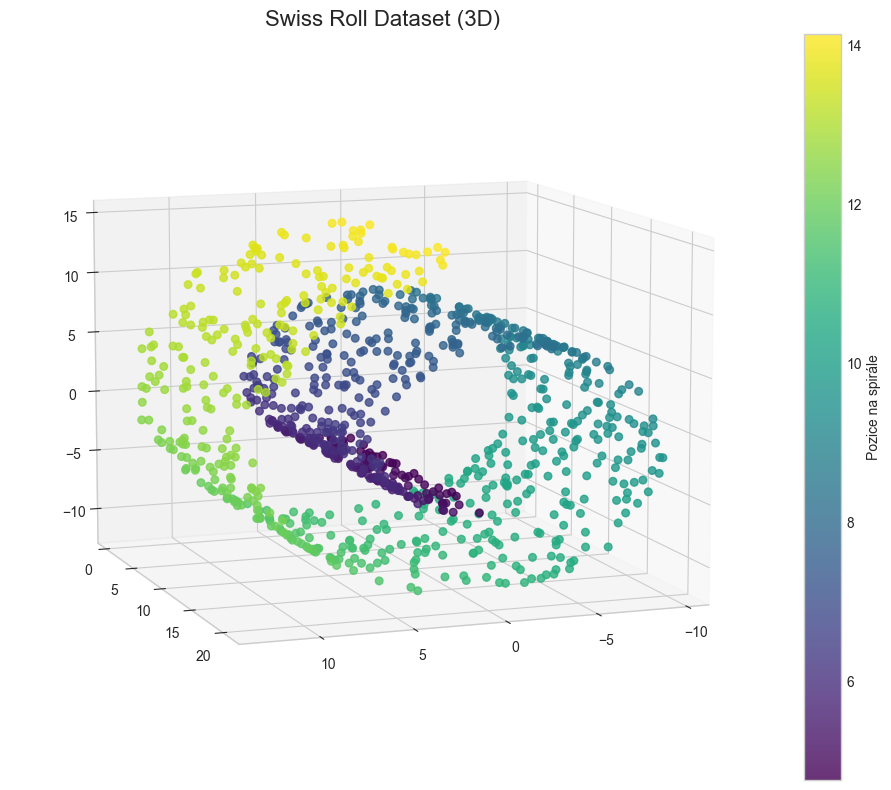

In [2]:
# Vytvoření Swiss Roll datasetu
n_samples = 1000
noise = 0.05
X_swiss_roll, color_swiss_roll = make_swiss_roll(n_samples=n_samples, noise=noise, random_state=42)

# Vizualizace původních 3D dat
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_swiss_roll[:, 0], X_swiss_roll[:, 1], X_swiss_roll[:, 2], 
                    c=color_swiss_roll, cmap='viridis', s=30, alpha=0.8)
ax.set_title('Swiss Roll Dataset (3D)', fontsize=16)
ax.view_init(elev=10, azim=70)  # Nastavíme úhel pohledu pro lepší zobrazení
plt.colorbar(scatter, label='Pozice na spirále')
plt.tight_layout()
plt.show()

Doba výpočtu LLE: 0.1324 sekund
Tvar původních dat: (1000, 3)
Tvar redukovaných dat: (1000, 2)


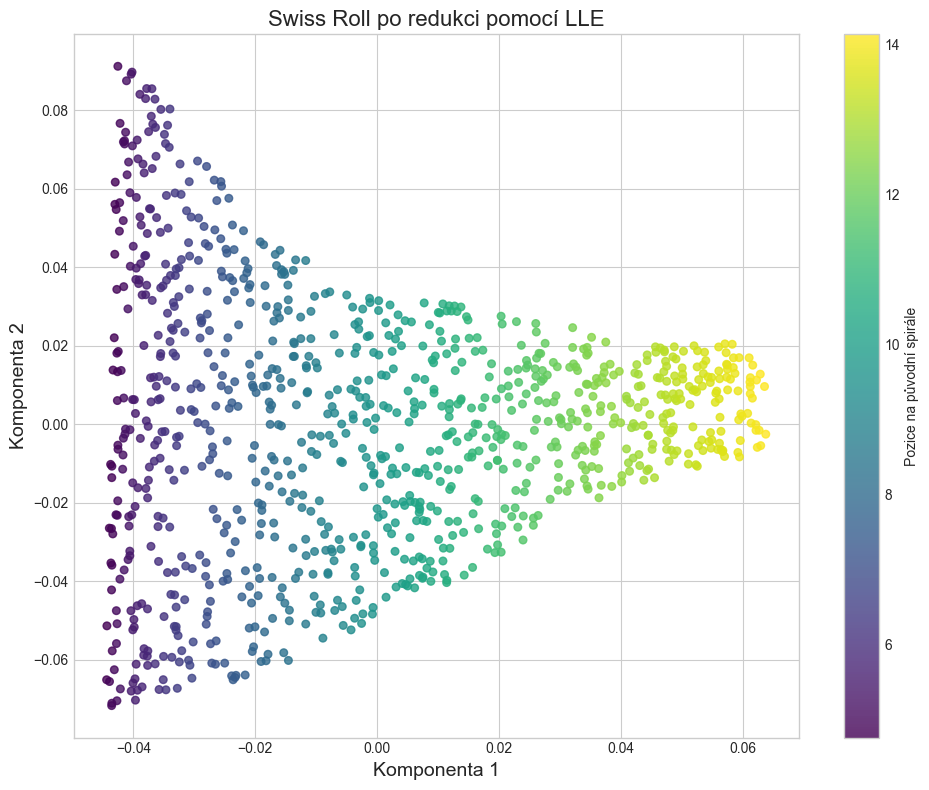

In [3]:
# Aplikace LLE na Swiss Roll dataset
start_time = time.time()

# Vytvoření a aplikace LLE
lle = LocallyLinearEmbedding(n_components=2,     # Počet výstupních dimenzí
                           n_neighbors=10,      # Počet sousedů
                           method='standard',   # Standardní LLE algoritmus
                           random_state=42)     # Pro reprodukovatelnost

X_lle = lle.fit_transform(X_swiss_roll)
lle_time = time.time() - start_time

print(f"Doba výpočtu LLE: {lle_time:.4f} sekund")
print(f"Tvar původních dat: {X_swiss_roll.shape}")
print(f"Tvar redukovaných dat: {X_lle.shape}")

# Vizualizace výsledků LLE
plt.figure(figsize=(10, 8))
plt.scatter(X_lle[:, 0], X_lle[:, 1], c=color_swiss_roll, cmap='viridis', s=30, alpha=0.8)
plt.colorbar(label='Pozice na původní spirále')
plt.title('Swiss Roll po redukci pomocí LLE', fontsize=16)
plt.xlabel('Komponenta 1', fontsize=14)
plt.ylabel('Komponenta 2', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

## 2. Porovnání s jinými metodami redukce dimenzionality

Porovnejme výsledky LLE s dalšími populárními metodami redukce dimenzionality na stejném datasetu.

Aplikuji PCA...
  Čas: 0.0100 s
Aplikuji LLE...
  Čas: 0.2331 s
Aplikuji Isomap...
  Čas: 0.4368 s
Aplikuji t-SNE...
  Čas: 5.4506 s
Aplikuji Spectral Embedding...
  Čas: 0.1441 s


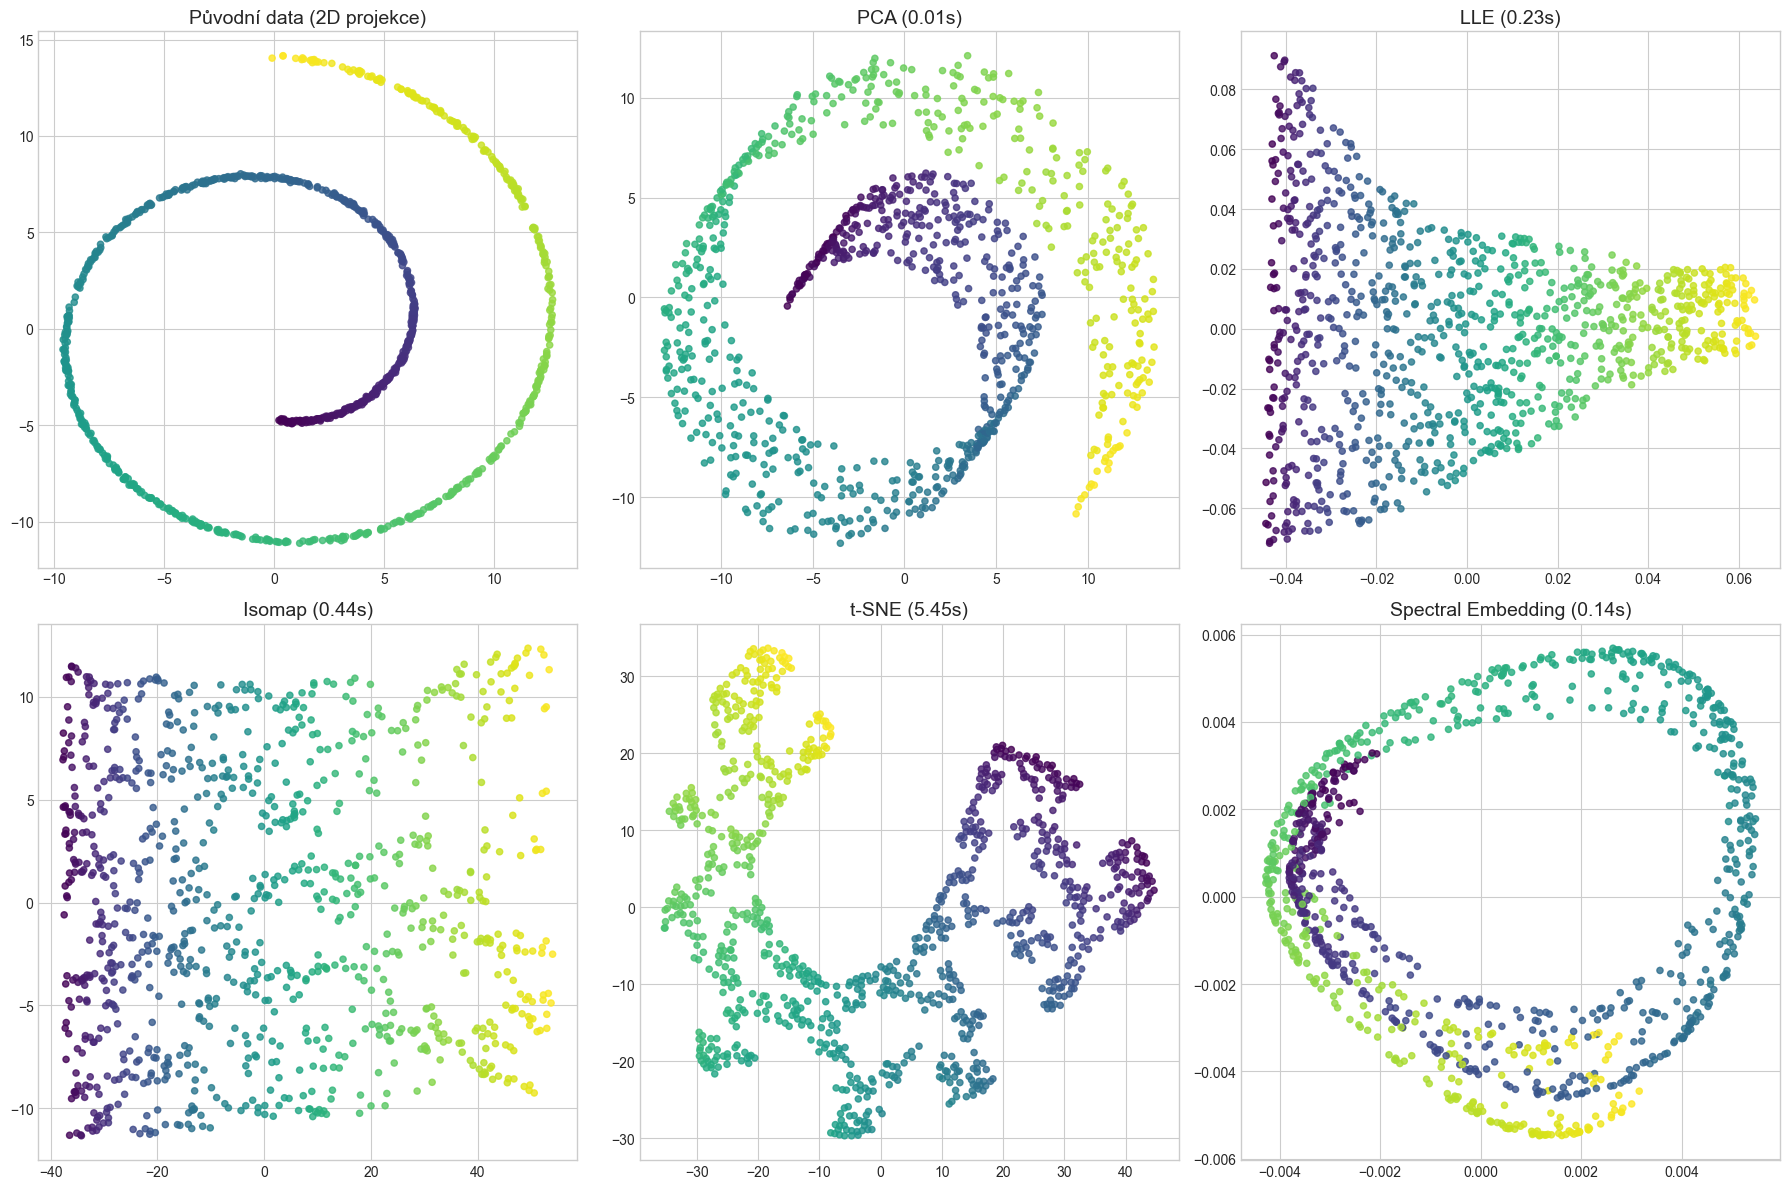

In [4]:
# Definice metod redukce dimenzionality
methods = {
    'PCA': PCA(n_components=2, random_state=42),
    'LLE': LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42),
    'Isomap': Isomap(n_components=2, n_neighbors=10),
    't-SNE': TSNE(n_components=2, random_state=42),
    'Spectral Embedding': SpectralEmbedding(n_components=2, random_state=42)
}

# Aplikace metod a měření času
results = {}
for name, method in methods.items():
    print(f"Aplikuji {name}...")
    start_time = time.time()
    results[name] = {
        'embedding': method.fit_transform(X_swiss_roll),
        'time': time.time() - start_time
    }
    print(f"  Čas: {results[name]['time']:.4f} s")

# Vizualizace výsledků všech metod
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Původní data ve 2D projekci (první a třetí dimenze)
axes[0].scatter(X_swiss_roll[:, 0], X_swiss_roll[:, 2], c=color_swiss_roll, cmap='viridis', s=20, alpha=0.8)
axes[0].set_title('Původní data (2D projekce)', fontsize=14)
axes[0].grid(True)

# Vizualizace výsledků jednotlivých metod
i = 1
for name, result in results.items():
    axes[i].scatter(result['embedding'][:, 0], result['embedding'][:, 1], 
                  c=color_swiss_roll, cmap='viridis', s=20, alpha=0.8)
    axes[i].set_title(f'{name} ({result["time"]:.2f}s)', fontsize=14)
    axes[i].grid(True)
    i += 1

plt.tight_layout()
plt.show()

## 3. Různé varianty LLE

LLE má několik variant, které se liší způsobem výpočtu a mohou být vhodnější pro specifické typy dat. Prozkoumejme hlavní varianty LLE dostupné v scikit-learn.

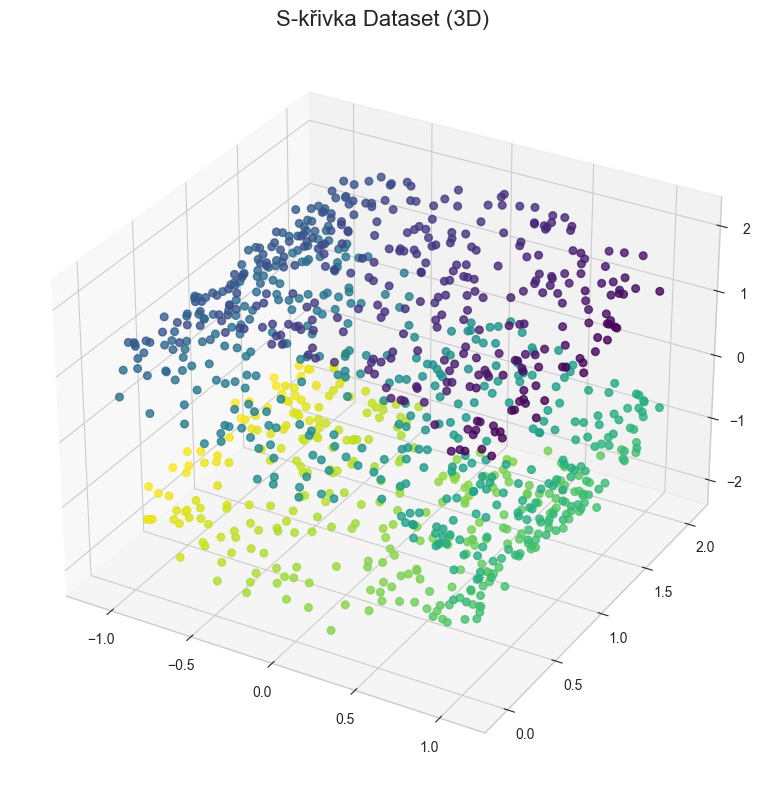

Aplikuji Standard LLE...
  Čas: 0.1015 s
Aplikuji Modified LLE...
  Čas: 1.9277 s
Aplikuji Hessian LLE...
  Čas: 1.0585 s
Aplikuji LTSA LLE...
  Čas: 1.4457 s


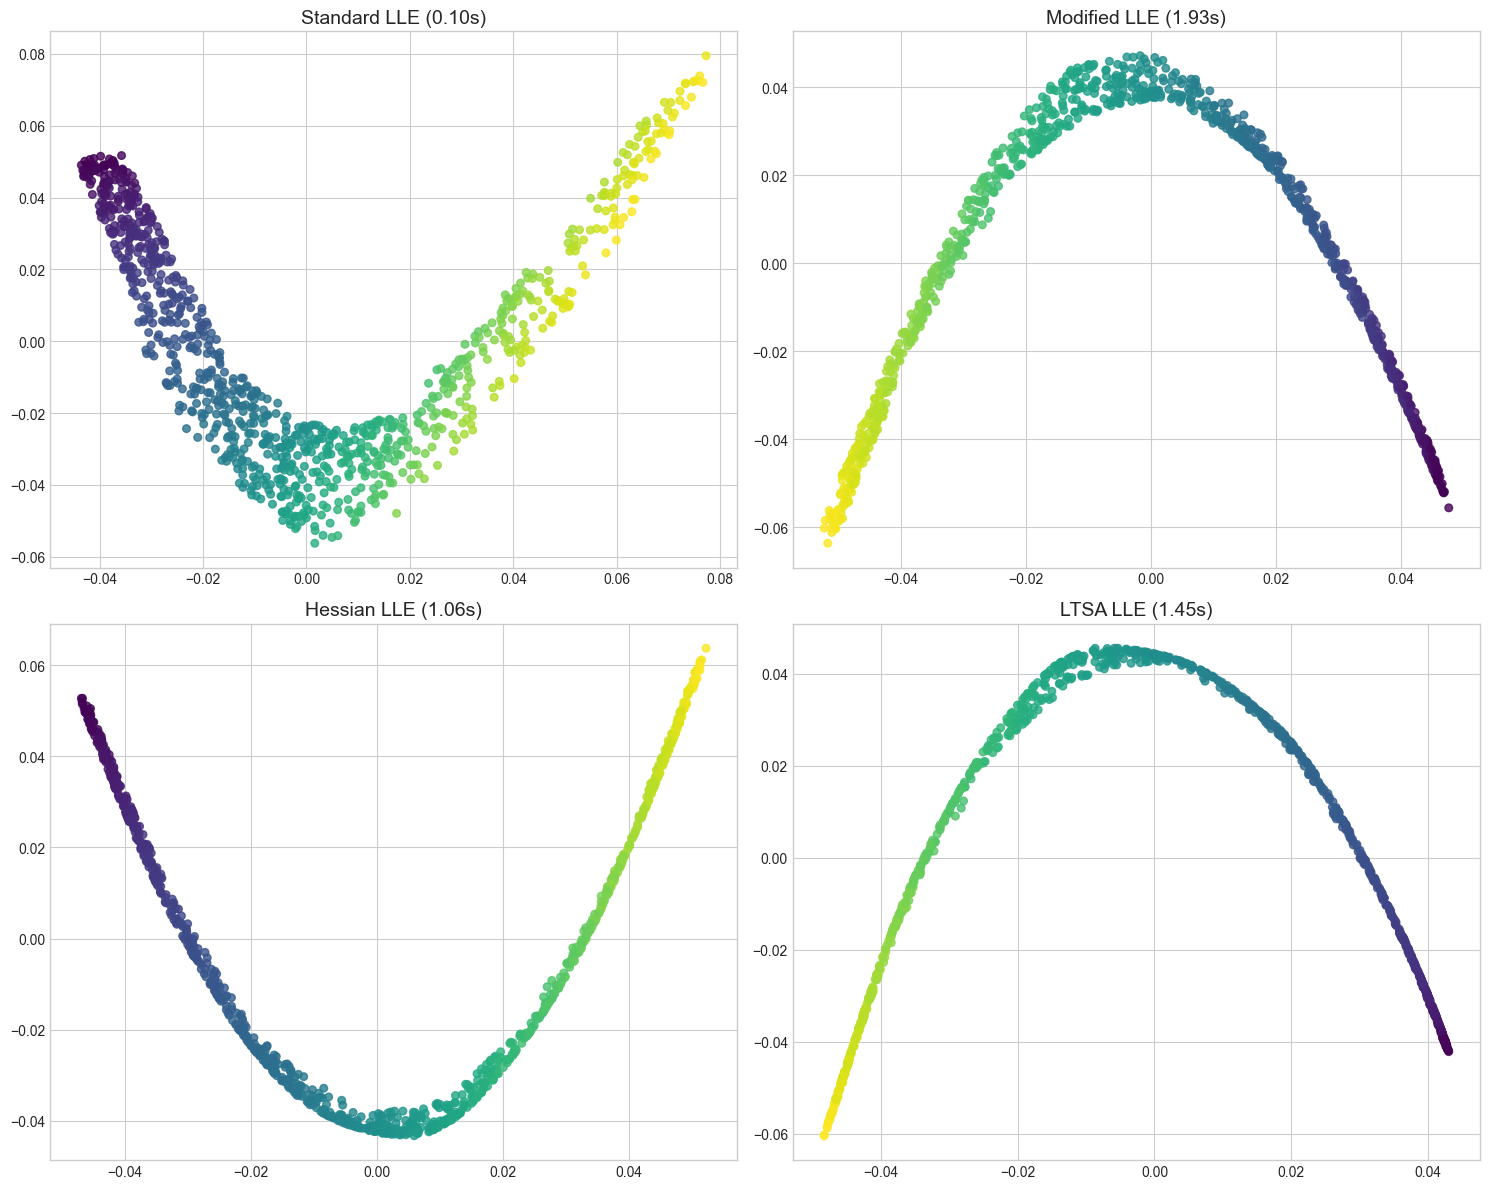

In [5]:
# Vytvoříme dataset S-křivky pro testování variant LLE
X_s_curve, color_s_curve = make_s_curve(n_samples=1000, noise=0.05, random_state=42)

# Vizualizace původních 3D dat
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_s_curve[:, 0], X_s_curve[:, 1], X_s_curve[:, 2], 
         c=color_s_curve, cmap='viridis', s=30, alpha=0.8)
ax.set_title('S-křivka Dataset (3D)', fontsize=16)
plt.tight_layout()
plt.show()

# Definice různých variant LLE
lle_methods = {
    'Standard LLE': LocallyLinearEmbedding(n_components=2, n_neighbors=10, 
                                        method='standard', random_state=42),
    'Modified LLE': LocallyLinearEmbedding(n_components=2, n_neighbors=10, 
                                         method='modified', random_state=42),
    'Hessian LLE': LocallyLinearEmbedding(n_components=2, n_neighbors=15, 
                                        method='hessian', random_state=42),
    'LTSA LLE': LocallyLinearEmbedding(n_components=2, n_neighbors=10, 
                                     method='ltsa', random_state=42)
}

# Aplikace různých variant LLE
lle_results = {}
for name, method in lle_methods.items():
    print(f"Aplikuji {name}...")
    try:
        start_time = time.time()
        lle_results[name] = {
            'embedding': method.fit_transform(X_s_curve),
            'time': time.time() - start_time
        }
        print(f"  Čas: {lle_results[name]['time']:.4f} s")
    except Exception as e:
        print(f"  Chyba: {e}")

# Vizualizace výsledků různých variant LLE
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (name, result) in enumerate(lle_results.items()):
    axes[i].scatter(result['embedding'][:, 0], result['embedding'][:, 1], 
                   c=color_s_curve, cmap='viridis', s=30, alpha=0.8)
    axes[i].set_title(f'{name} ({result["time"]:.2f}s)', fontsize=14)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

## 4. Vliv parametru n_neighbors

Jedním z klíčových parametrů LLE je `n_neighbors`, který určuje, kolik nejbližších sousedů se použije pro rekonstrukci každého bodu. Prozkoumejme, jak tento parametr ovlivňuje výsledky.

Testuji n_neighbors=5...
  Čas: 0.1495 s
Testuji n_neighbors=10...
  Čas: 0.1451 s
Testuji n_neighbors=20...
  Čas: 0.1096 s
Testuji n_neighbors=50...
  Čas: 0.2312 s
Testuji n_neighbors=100...
  Čas: 0.3704 s


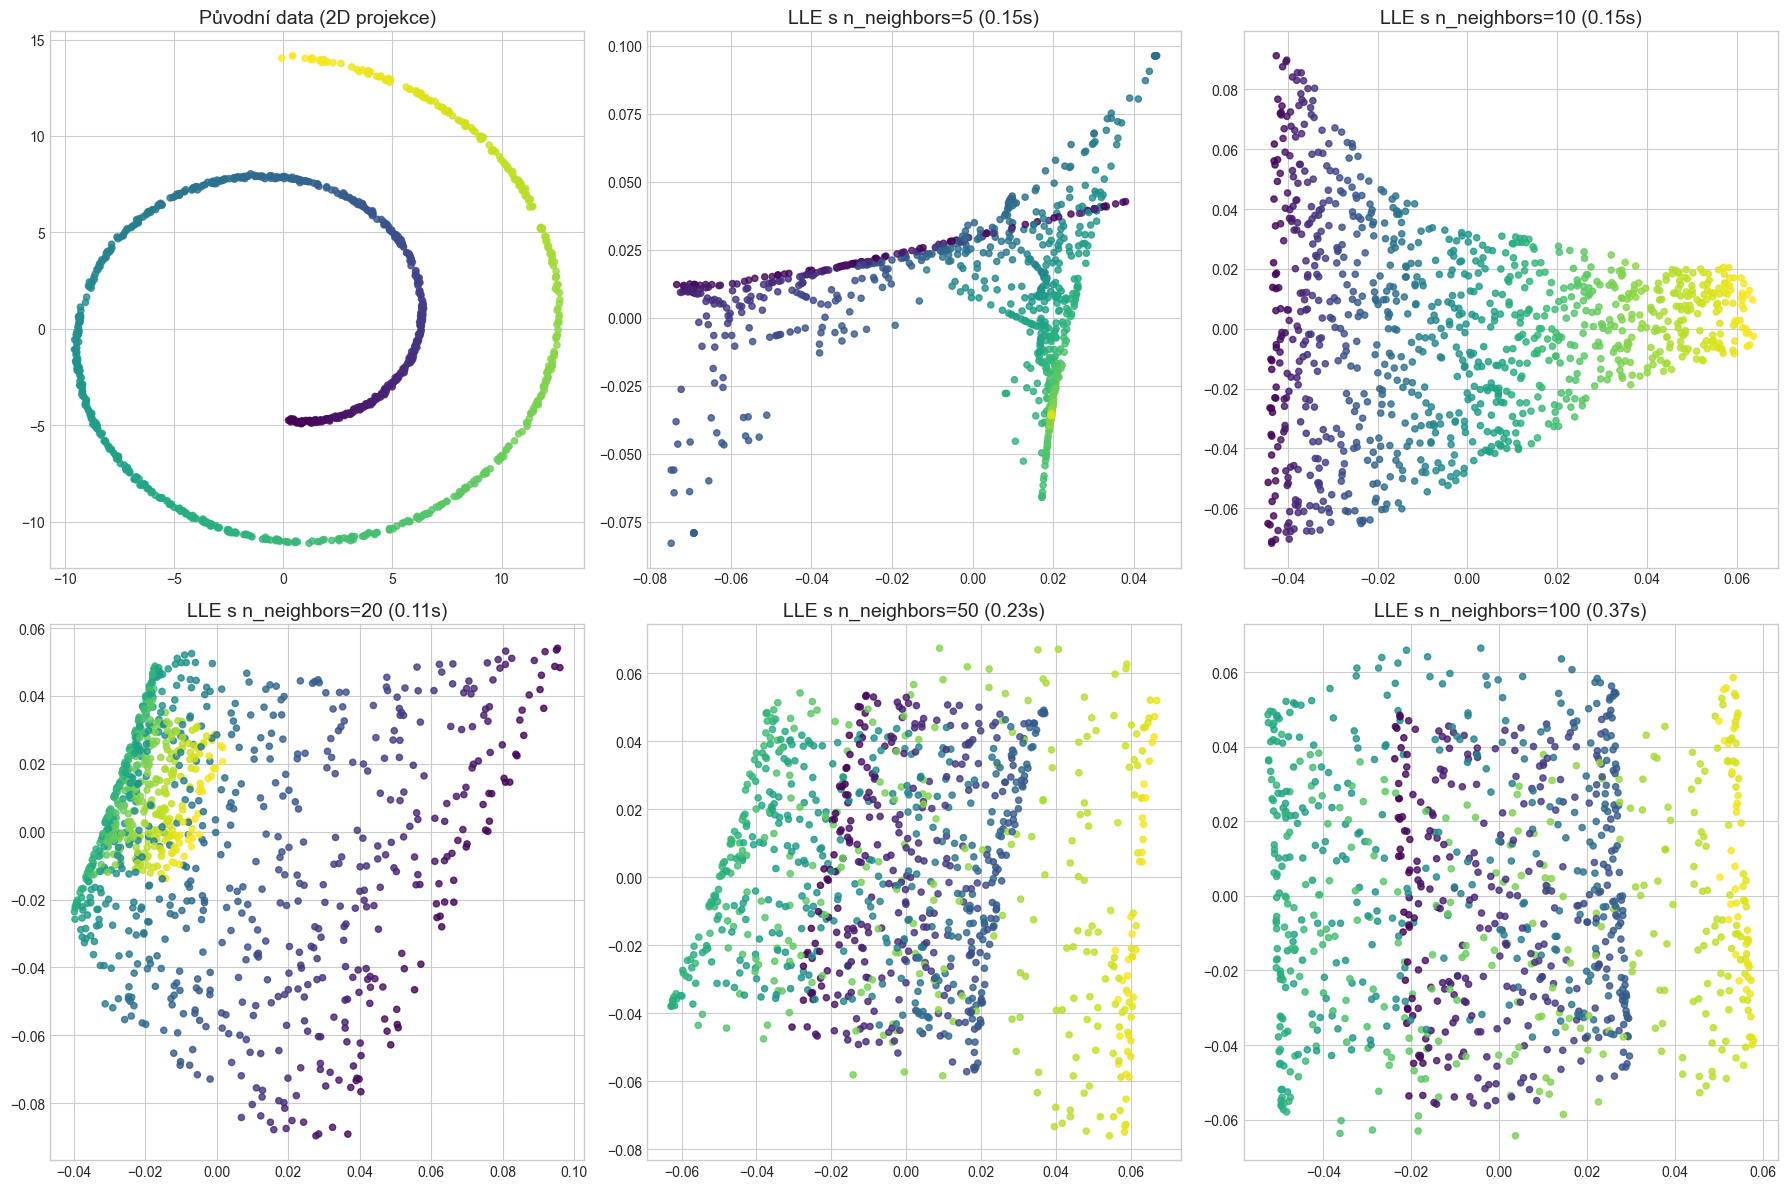

In [6]:
# Testování různých hodnot n_neighbors
neighbors_list = [5, 10, 20, 50, 100]
neighbors_results = {}

for n in neighbors_list:
    print(f"Testuji n_neighbors={n}...")
    start_time = time.time()
    lle = LocallyLinearEmbedding(n_components=2, n_neighbors=n, method='standard', random_state=42)
    
    try:
        neighbors_results[n] = {
            'embedding': lle.fit_transform(X_swiss_roll),
            'time': time.time() - start_time
        }
        print(f"  Čas: {neighbors_results[n]['time']:.4f} s")
    except Exception as e:
        print(f"  Chyba při n_neighbors={n}: {e}")

# Vizualizace výsledků pro různé n_neighbors
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Původní data ve 2D projekci
axes[0].scatter(X_swiss_roll[:, 0], X_swiss_roll[:, 2], c=color_swiss_roll, cmap='viridis', s=20, alpha=0.8)
axes[0].set_title('Původní data (2D projekce)', fontsize=14)
axes[0].grid(True)

# Výsledky pro různé n_neighbors
i = 1
for n, result in neighbors_results.items():
    axes[i].scatter(result['embedding'][:, 0], result['embedding'][:, 1], 
                   c=color_swiss_roll, cmap='viridis', s=20, alpha=0.8)
    axes[i].set_title(f'LLE s n_neighbors={n} ({result["time"]:.2f}s)', fontsize=14)
    axes[i].grid(True)
    i += 1

plt.tight_layout()
plt.show()

## 5. Aplikace na reálná data - MNIST Digits

Nyní aplikujeme LLE na reálný dataset - MNIST digits (ručně psané číslice).

Tvar dat: (1797, 64)
Počet tříd: 10


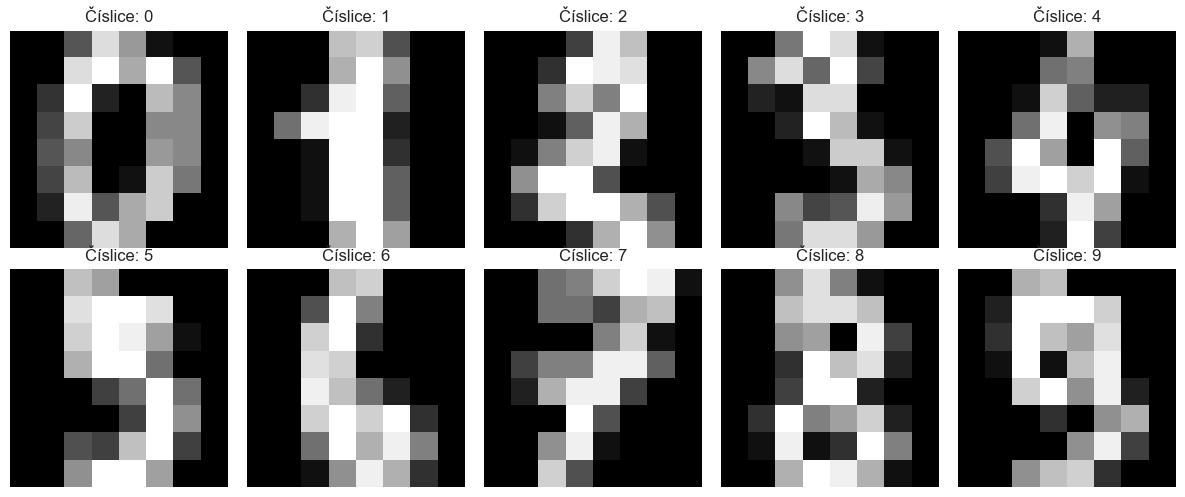

In [7]:
# Načtení datasetu MNIST digits
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print(f"Tvar dat: {X_digits.shape}")
print(f"Počet tříd: {len(np.unique(y_digits))}")

# Zobrazení několika příkladů číslic
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Číslice: {y_digits[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
# Standardizace dat
scaler = StandardScaler()
X_digits_scaled = scaler.fit_transform(X_digits)

# Aplikace LLE na MNIST digits
start_time = time.time()
lle_digits = LocallyLinearEmbedding(n_components=2, n_neighbors=15, method='standard', random_state=42)
X_digits_lle = lle_digits.fit_transform(X_digits_scaled)
lle_digits_time = time.time() - start_time
print(f"Doba výpočtu LLE pro MNIST: {lle_digits_time:.4f} sekund")

# Pro porovnání aplikujeme PCA
start_time = time.time()
pca_digits = PCA(n_components=2, random_state=42)
X_digits_pca = pca_digits.fit_transform(X_digits_scaled)
pca_digits_time = time.time() - start_time
print(f"Doba výpočtu PCA pro MNIST: {pca_digits_time:.4f} sekund")

Doba výpočtu LLE pro MNIST: 0.4859 sekund
Doba výpočtu PCA pro MNIST: 0.0020 sekund


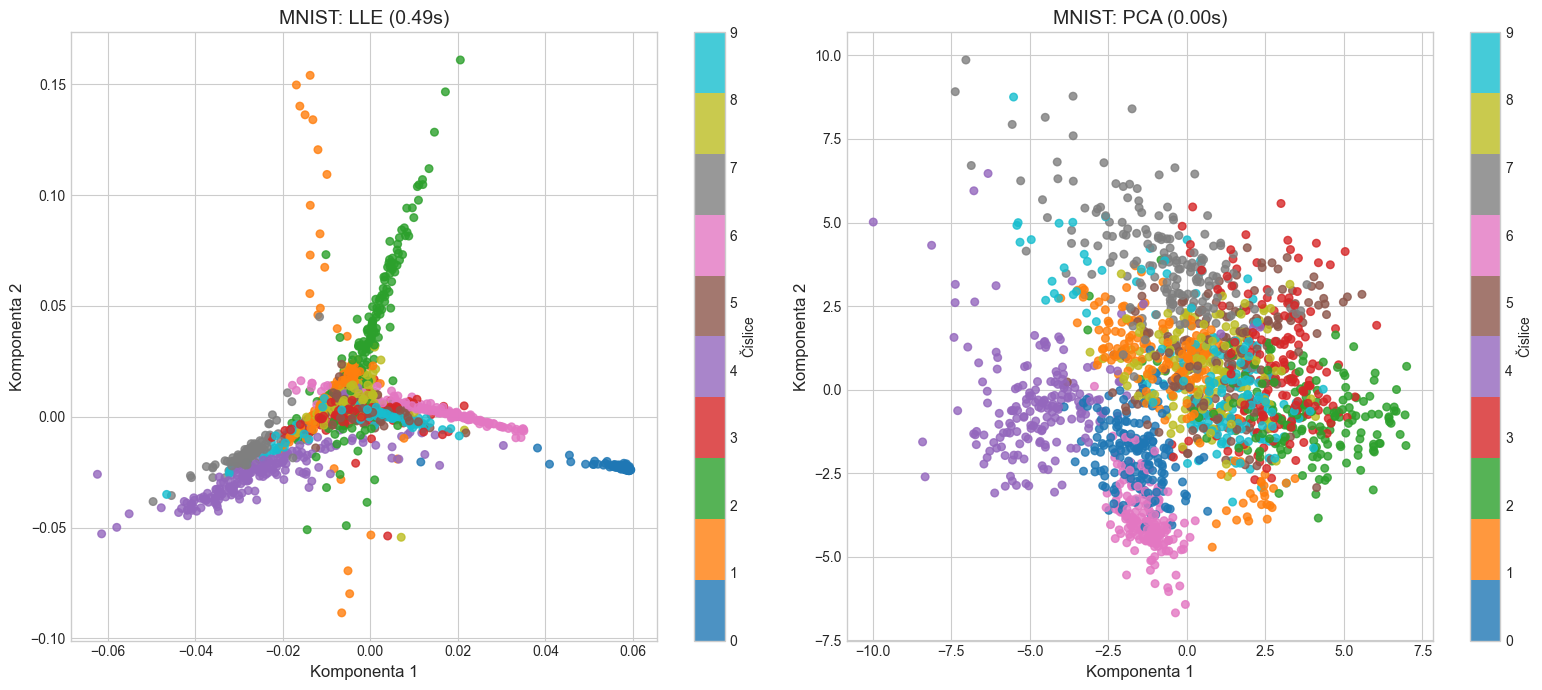

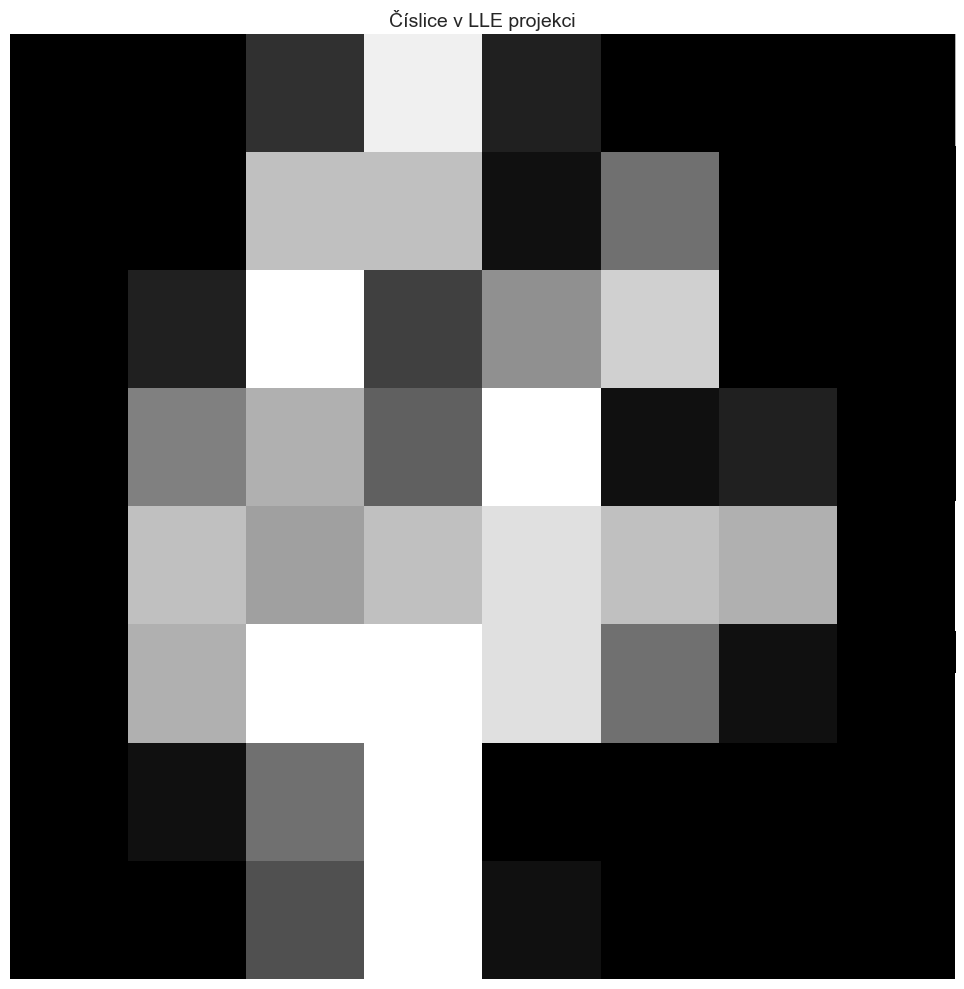

In [9]:
# Vizualizace výsledků LLE a PCA pro MNIST dataset
plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_digits_lle[:, 0], X_digits_lle[:, 1], 
                     c=y_digits, cmap='tab10', s=30, alpha=0.8)
plt.colorbar(label='Číslice')
plt.title(f'MNIST: LLE ({lle_digits_time:.2f}s)', fontsize=14)
plt.xlabel('Komponenta 1', fontsize=12)
plt.ylabel('Komponenta 2', fontsize=12)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X_digits_pca[:, 0], X_digits_pca[:, 1], 
          c=y_digits, cmap='tab10', s=30, alpha=0.8)
plt.colorbar(label='Číslice')
plt.title(f'MNIST: PCA ({pca_digits_time:.2f}s)', fontsize=14)
plt.xlabel('Komponenta 1', fontsize=12)
plt.ylabel('Komponenta 2', fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()

# Zobrazení vybraných číslic přímo v embeddigu
def plot_digits_in_embedding(X_embedded, images, targets, nrows=10, ncols=10, title=""):
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.scatter(X_embedded[:, 0], X_embedded[:, 1], c=targets, cmap='tab10', alpha=0.1)
    
    # Vybereme náhodně některé body pro zobrazení
    np.random.seed(42)
    indices = np.random.choice(range(len(X_embedded)), nrows * ncols, replace=False)
    
    for i, idx in enumerate(indices):
        # Pozice v embeddigu
        x, y = X_embedded[idx, 0], X_embedded[idx, 1]
        
        # Vložení obrázku
        img = images[idx].reshape(8, 8)
        img = (img - img.min()) / (img.max() - img.min())  # Normalizace pro zobrazení
        
        # Velikost obrázku v grafu
        img_size = 0.03
        
        # Přidání obrázku na pozici v embeddigu
        ax.imshow(img, extent=(x-img_size, x+img_size, y-img_size, y+img_size), 
                  cmap='gray', interpolation='nearest', zorder=2)
    
    ax.set_title(title, fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Zobrazení číslic v LLE projekci
plot_digits_in_embedding(X_digits_lle, digits.images, y_digits, title="Číslice v LLE projekci")

## 6. Použití LLE pro klasifikaci

Vyzkoušíme použití LLE jako metody předzpracování dat před klasifikací.

Metoda: Původní data
  Přesnost: 0.9685
  Celkový čas: 0.0100s
Metoda: PCA
  Přesnost: 0.9370
  Celkový čas: 0.0380s
Metoda: LLE
  Přesnost: 0.9148
  Celkový čas: 0.4586s
Metoda: Isomap
  Přesnost: 0.9574
  Celkový čas: 1.0700s
Metoda: Spectral Embedding
  Přesnost: 0.1963
  Celkový čas: 0.4754s

Shrnutí výsledků:
               Metoda  Přesnost  Redukce dimenzí [s]  Trénování [s]  \
0        Původní data    0.9685               0.0000          0.002   
1                 PCA    0.9370               0.0020          0.002   
2                 LLE    0.9148               0.4241          0.001   
3              Isomap    0.9574               1.0345          0.003   
4  Spectral Embedding    0.1963               0.4263          0.002   

   Predikce [s]  Dimenze  
0        0.0080       64  
1        0.0340       10  
2        0.0335       10  
3        0.0325       10  
4        0.0470       10  


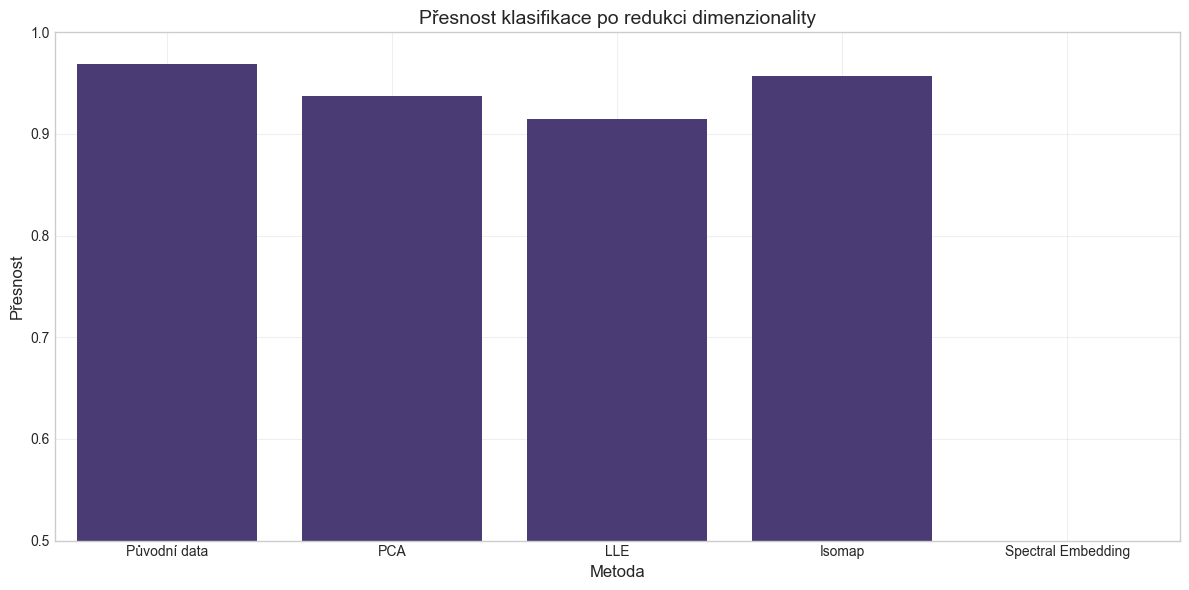

In [10]:
# Rozdělení dat na trénovací a testovací sadu
X_train, X_test, y_train, y_test = train_test_split(
    X_digits, y_digits, test_size=0.3, random_state=42)

# Standardizace dat
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Různé metody redukce dimenzionality
methods = {
    'Původní data': None,
    'PCA': PCA(n_components=10, random_state=42),
    'LLE': LocallyLinearEmbedding(n_components=10, n_neighbors=15, random_state=42),
    'Isomap': Isomap(n_components=10, n_neighbors=15),
    'Spectral Embedding': SpectralEmbedding(n_components=10, random_state=42)
}

# Klasifikátor
clf = KNeighborsClassifier(n_neighbors=3)

results = []
for name, reducer in methods.items():
    print(f"Metoda: {name}")
    
    # Aplikace redukce dimenzionality
    if reducer is None:
        X_train_reduced = X_train_scaled
        X_test_reduced = X_test_scaled
        reduction_time = 0
    else:
        start_time = time.time()
        X_train_reduced = reducer.fit_transform(X_train_scaled)
        X_test_reduced = reducer.transform(X_test_scaled) if hasattr(reducer, 'transform') else reducer.fit_transform(X_test_scaled)
        reduction_time = time.time() - start_time
    
    # Trénování a predikce
    start_time = time.time()
    clf.fit(X_train_reduced, y_train)
    train_time = time.time() - start_time
    
    start_time = time.time()
    y_pred = clf.predict(X_test_reduced)
    predict_time = time.time() - start_time
    
    # Vyhodnocení
    acc = accuracy_score(y_test, y_pred)
    
    results.append({
        'Metoda': name,
        'Přesnost': acc,
        'Redukce dimenzí [s]': reduction_time,
        'Trénování [s]': train_time,
        'Predikce [s]': predict_time,
        'Dimenze': X_train_reduced.shape[1]
    })
    
    print(f"  Přesnost: {acc:.4f}")
    print(f"  Celkový čas: {reduction_time + train_time + predict_time:.4f}s")

# Zobrazení výsledků
results_df = pd.DataFrame(results)
print("\nShrnutí výsledků:")
print(results_df.round(4))

# Vizualizace přesnosti
plt.figure(figsize=(12, 6))
sns.barplot(x='Metoda', y='Přesnost', data=results_df)
plt.title('Přesnost klasifikace po redukci dimenzionality', fontsize=14)
plt.xlabel('Metoda', fontsize=12)
plt.ylabel('Přesnost', fontsize=12)
plt.ylim(0.5, 1.0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Škálování LLE s rostoucí velikostí datasetu

Prozkoumejme, jak se LLE škáluje s rostoucím počtem vzorků a dimenzí dat.

n=100, LLE: 0.0260s, PCA: 0.0010s, poměr: 25.8x
n=500, LLE: 0.1025s, PCA: 0.0020s, poměr: 51.2x
n=1000, LLE: 0.1498s, PCA: 0.0010s, poměr: 150.6x
n=2000, LLE: 0.2807s, PCA: 0.0010s, poměr: 281.6x
n=3000, LLE: 0.7102s, PCA: 0.0010s, poměr: 710.6x


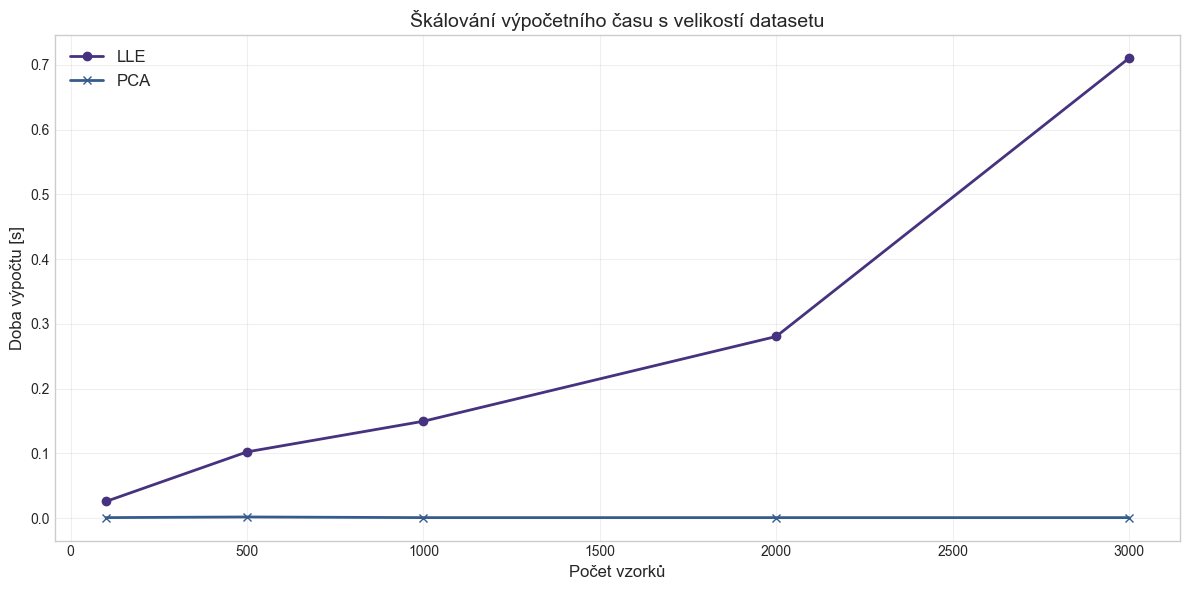

In [11]:
# Test škálování s velikostí datasetu
sample_sizes = [100, 500, 1000, 2000, 3000]
dimensionality = 20  # Pevná dimensionalita

times_lle = []
times_pca = []

for n in sample_sizes:
    # Vytvoření syntetických dat
    X_blob, _ = make_blobs(n_samples=n, n_features=dimensionality, 
                          centers=3, random_state=42)
    
    # LLE
    start_time = time.time()
    try:
        LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42).fit_transform(X_blob)
        lle_time = time.time() - start_time
    except Exception as e:
        print(f"Chyba LLE při n={n}: {e}")
        lle_time = np.nan
    times_lle.append(lle_time)
    
    # PCA (pro porovnání)
    start_time = time.time()
    PCA(n_components=2, random_state=42).fit_transform(X_blob)
    pca_time = time.time() - start_time
    times_pca.append(pca_time)
    
    print(f"n={n}, LLE: {lle_time:.4f}s, PCA: {pca_time:.4f}s, poměr: {lle_time/pca_time:.1f}x")

# Vizualizace výsledků
plt.figure(figsize=(12, 6))
plt.plot(sample_sizes, times_lle, 'o-', linewidth=2, label='LLE')
plt.plot(sample_sizes, times_pca, 'x-', linewidth=2, label='PCA')
plt.xlabel('Počet vzorků', fontsize=12)
plt.ylabel('Doba výpočtu [s]', fontsize=12)
plt.title('Škálování výpočetního času s velikostí datasetu', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

d=10, LLE: 0.1086s, PCA: 0.0010s, poměr: 108.6x
d=20, LLE: 0.0505s, PCA: 0.0010s, poměr: 50.5x
d=50, LLE: 0.0420s, PCA: 0.0020s, poměr: 21.0x
d=100, LLE: 0.0455s, PCA: 0.0140s, poměr: 3.3x
d=200, LLE: 0.0600s, PCA: 0.0376s, poměr: 1.6x


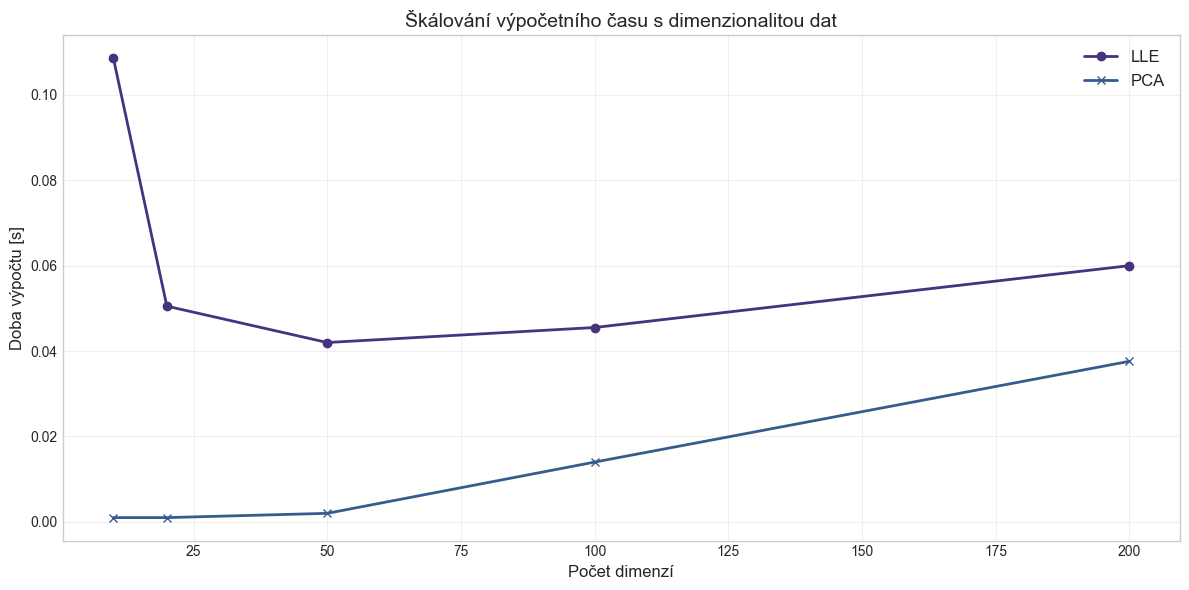

In [12]:
# Test škálování s dimenzionalitou dat
dimensions = [10, 20, 50, 100, 200]
n_samples = 500  # Pevný počet vzorků

dim_times_lle = []
dim_times_pca = []

for d in dimensions:
    # Vytvoření syntetických dat
    X_blob, _ = make_blobs(n_samples=n_samples, n_features=d, 
                          centers=3, random_state=42)
    
    # LLE
    start_time = time.time()
    try:
        LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42).fit_transform(X_blob)
        lle_time = time.time() - start_time
    except Exception as e:
        print(f"Chyba LLE při d={d}: {e}")
        lle_time = np.nan
    dim_times_lle.append(lle_time)
    
    # PCA (pro porovnání)
    start_time = time.time()
    PCA(n_components=2, random_state=42).fit_transform(X_blob)
    pca_time = time.time() - start_time
    dim_times_pca.append(pca_time)
    
    print(f"d={d}, LLE: {lle_time:.4f}s, PCA: {pca_time:.4f}s, poměr: {lle_time/pca_time:.1f}x")

# Vizualizace výsledků
plt.figure(figsize=(12, 6))
plt.plot(dimensions, dim_times_lle, 'o-', linewidth=2, label='LLE')
plt.plot(dimensions, dim_times_pca, 'x-', linewidth=2, label='PCA')
plt.xlabel('Počet dimenzí', fontsize=12)
plt.ylabel('Doba výpočtu [s]', fontsize=12)
plt.title('Škálování výpočetního času s dimenzionalitou dat', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 8. Analýza obličejových dat

Pro zajímavost aplikujeme LLE na dataset obličejů Olivetti, který obsahuje fotografie 40 různých lidí v různých pózách.

Tvar dat: (400, 4096)
Počet osob: 40


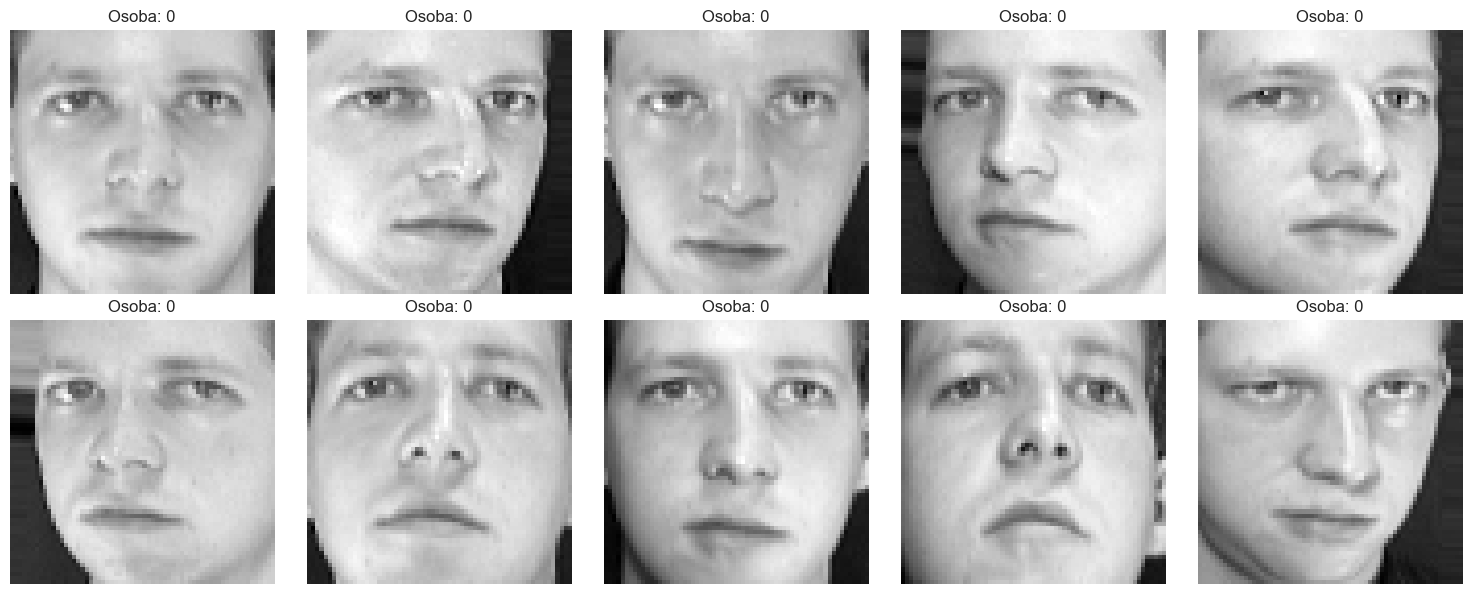

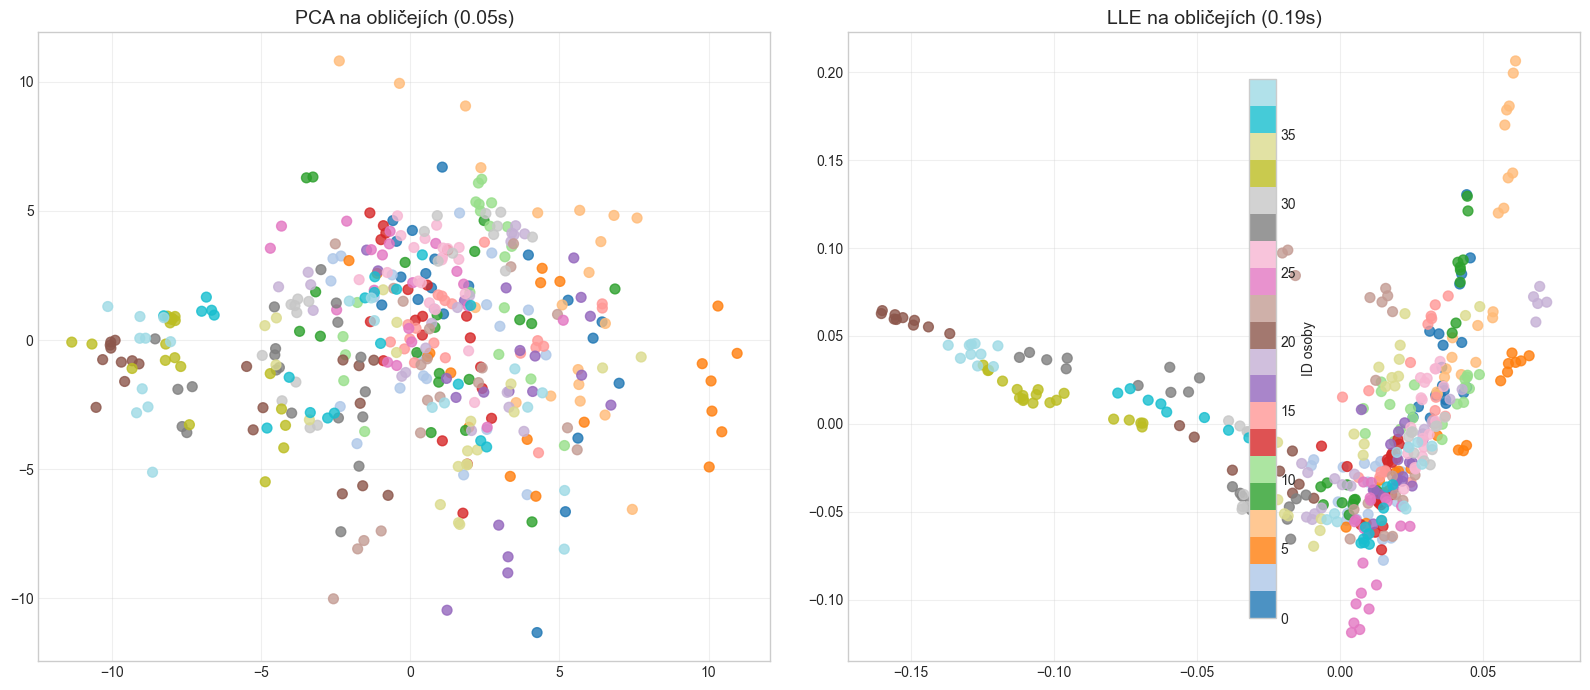

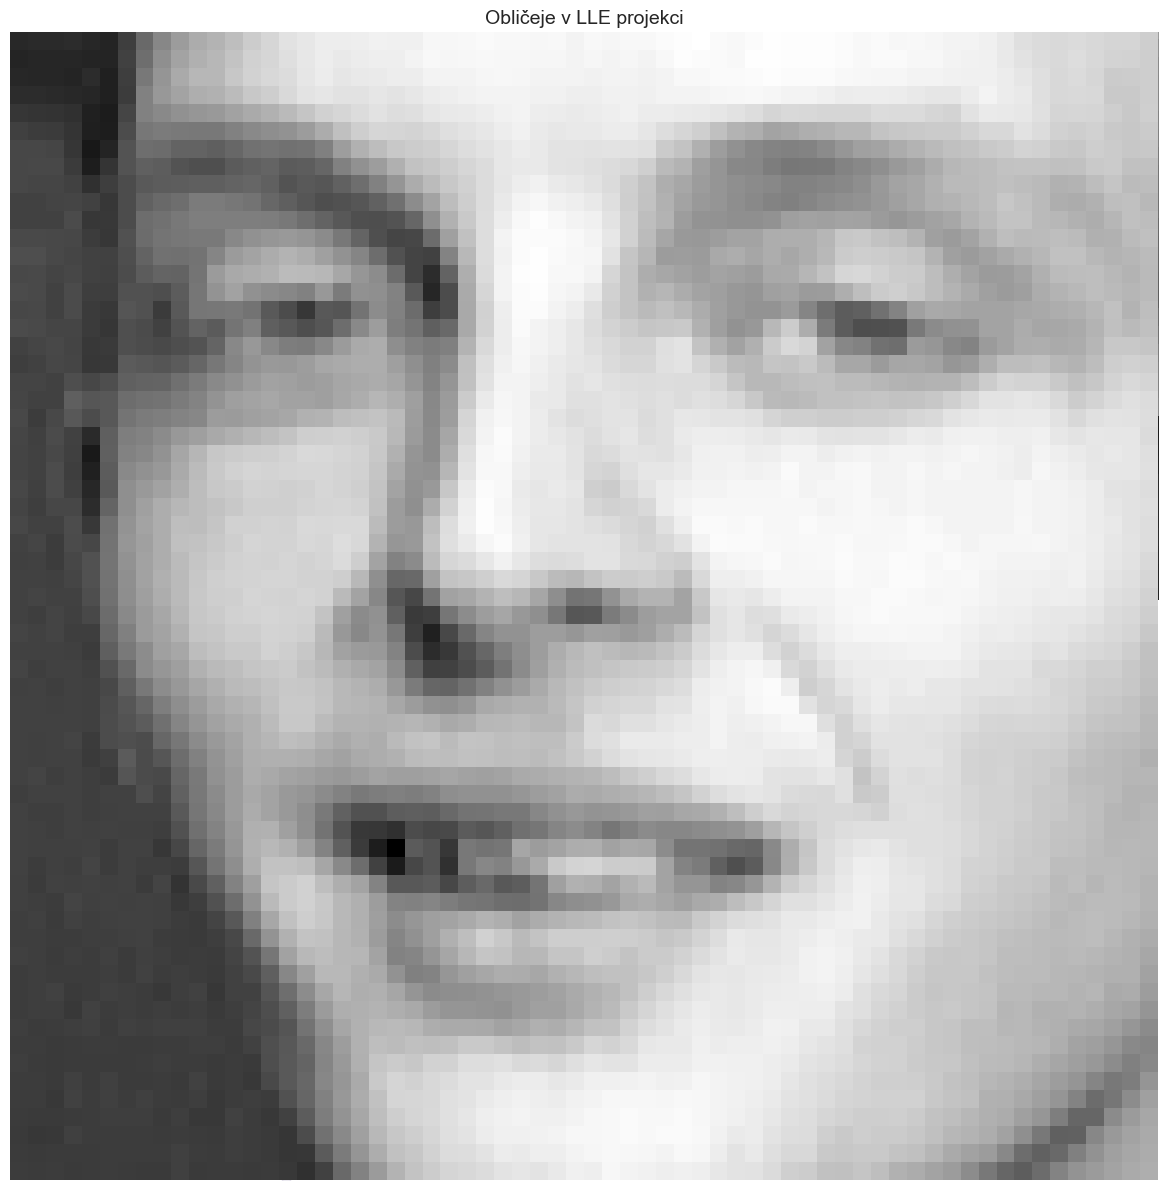

In [13]:
try:
    # Načtení datasetu obličejů
    faces = fetch_olivetti_faces()
    X_faces = faces.data
    y_faces = faces.target
    
    print(f"Tvar dat: {X_faces.shape}")
    print(f"Počet osob: {len(np.unique(y_faces))}")
    
    # Zobrazení několika obličejů
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(faces.images[i], cmap='gray')
        ax.set_title(f'Osoba: {y_faces[i]}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Aplikace LLE a PCA na obličeje
    reducer_faces = {
        'PCA': PCA(n_components=2, random_state=42),
        'LLE': LocallyLinearEmbedding(n_components=2, n_neighbors=15, random_state=42)
    }
    
    # Výpočet a vizualizace embeddings
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    for i, (name, reducer) in enumerate(reducer_faces.items()):
        start_time = time.time()
        X_faces_reduced = reducer.fit_transform(X_faces)
        reducer_time = time.time() - start_time
        
        # Vizualizace
        scatter = axes[i].scatter(X_faces_reduced[:, 0], X_faces_reduced[:, 1], 
                                 c=y_faces, cmap='tab20', s=50, alpha=0.8)
        axes[i].set_title(f'{name} na obličejích ({reducer_time:.2f}s)', fontsize=14)
        axes[i].grid(True, alpha=0.3)
        
    plt.colorbar(scatter, ax=axes, label='ID osoby')
    plt.tight_layout()
    plt.show()
    
    # Zobrazení obličejů přímo v embedding prostoru
    def plot_faces_embedding(X_embedded, images, targets, title):
        fig, ax = plt.subplots(figsize=(14, 12))
        ax.scatter(X_embedded[:, 0], X_embedded[:, 1], alpha=0.1)
        
        # Vybereme některé body pro zobrazení
        step = 2  # Zobrazíme každý druhý obličej pro přehlednost
        
        for idx in range(0, len(images), step):
            # Pozice v embeddigu
            x, y = X_embedded[idx, 0], X_embedded[idx, 1]
            
            # Vložení obrázku
            img = images[idx].reshape(64, 64)
            img = (img - img.min()) / (img.max() - img.min())  # Normalizace
            
            # Velikost obrázku v grafu
            img_size = 0.02
            
            # Přidání obrázku na pozici v embeddigu
            ax.imshow(img, extent=(x-img_size, x+img_size, y-img_size, y+img_size), 
                      cmap='gray', interpolation='nearest', zorder=2)
        
        ax.set_title(title, fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    # Zobrazení obličejů v LLE projekci
    lle_faces = LocallyLinearEmbedding(n_components=2, n_neighbors=15, random_state=42)
    X_faces_lle = lle_faces.fit_transform(X_faces)
    plot_faces_embedding(X_faces_lle, faces.images, y_faces, "Obličeje v LLE projekci")
except Exception as e:
    print(f"Nepodařilo se načíst nebo zpracovat dataset obličejů: {e}")

## 9. Shrnutí a doporučení pro použití LLE

### Výhody LLE:

1. **Zachování lokální struktury** - LLE je vynikající v zachování lokálních vztahů mezi datovými body.
2. **Nelineární redukce** - Dokáže efektivně odhalit nelineární variety v datech, kde lineární metody jako PCA selhávají.
3. **Různé varianty** - Nabízí několik variant (standard, modified, Hessian, LTSA), které se mohou lépe hodit pro různé typy dat.
4. **Bez potřeby definování vzdálenostní funkce** - Na rozdíl od některých jiných metod se zaměřuje na rekonstrukční váhy místo explicitních vzdáleností.
5. **Interpretovatelné výsledky** - Často poskytuje intuitivní vizualizaci dat, která může odhalit skryté struktury.

### Nevýhody LLE:

1. **Výpočetní náročnost** - Škáluje se špatně s počtem vzorků (O(n²) nebo vyšší složitost).
2. **Paměťová náročnost** - Pro velké datasety může být paměťově náročné.
3. **Citlivost na parametr n_neighbors** - Výsledky mohou být velmi závislé na správném nastavení počtu sousedů.
4. **Problémy s řídkými daty** - Může mít potíže s daty, která obsahují oblasti s velmi rozdílnou hustotou bodů.
5. **Nejednoznačné mapování nových dat** - Nemá přímou metodu pro transformaci nových bodů (musí se přetrénovat nebo použít aproximace).

### Doporučení pro použití:

- **Kdy použít LLE**:
  - Pro vizualizaci dat s nelineární strukturou
  - Když je důležité zachovat lokální vztahy mezi body
  - Pro menší až střední datasety (stovky až jednotky tisíc vzorků)
  - Jako krok předzpracování pro další algoritmy učení

- **Kdy zvážit jiné metody**:
  - Pro velmi velké datasety: t-SNE nebo UMAP
  - Když je důležitější zachovat globální strukturu: Isomap
  - Pro rychlou explorační analýzu: PCA
  - Když potřebujete jasně interpretovatelné dimenze: PCA nebo NMF

- **Optimální nastavení parametrů**:
  - `n_neighbors`: Kritický parametr, typicky začněte s hodnotami 5-20 a experimentujte
  - `method`: Standardní LLE pro začátek, ale vyzkoušejte modified pro stabilnější výsledky nebo Hessian pro složitější struktury
  - `reg`: Přidejte regularizaci (1e-3 je dobrý výchozí bod), když výpočet není stabilní
  - `n_components`: Pro vizualizaci 2-3, pro předzpracování zkuste různé hodnoty

### Závěr:

LLE je mocná nelineární metoda redukce dimenzionality, která vyniká v zachování lokálních vztahů v datech. Je obzvláště užitečná pro vizualizaci a průzkum dat s nelineární strukturou. Její hlavní omezení spočívá ve špatné škálovatelnosti s velikostí datasetu, což ji činí méně vhodnou pro velmi velké datasety. Pro menší až střední datasety však může LLE odhalit struktury, které lineární metody jako PCA nezachytí.